In [ ]:
"""
AI Ethics Radar - Zero-Shot Multi-Label Classification + Preprocessing + EDA
Stage 1: Label all articles with 6 main categories
Stage 2: Label AI articles with 12 ethics issues
Stage 3: Preprocessing (convert to binary, split data)
Stage 4: EDA and visualization

Hardware: Kaggle T4 x2 GPU
"""

import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns


# File paths
INPUT_FILE = '/kaggle/input/aiarticles/articles.jsonl'  # Update this path
OUTPUT_STAGE1 = 'labeled_stage1.csv'
OUTPUT_STAGE2 = 'labeled_stage2.csv'
OUTPUT_COMBINED = 'labeled_combined.csv'
OUTPUT_BINARY = 'labeled_binary.csv'
OUTPUT_TRAIN_STAGE1 = 'train_stage1.csv'
OUTPUT_VAL_STAGE1 = 'val_stage1.csv'
OUTPUT_TEST_STAGE1 = 'test_stage1.csv'
OUTPUT_TRAIN_STAGE2 = 'train_stage2.csv'
OUTPUT_VAL_STAGE2 = 'val_stage2.csv'
OUTPUT_TEST_STAGE2 = 'test_stage2.csv'

# Stage 1: Main Categories
MAIN_CATEGORIES = [
    "Artificial Intelligence",
    "Technology", 
    "Business",
    "Politics",
    "Sports",
    "Others"
]

# Stage 2: AI Ethics Issues
ETHICS_LABELS = [
    "Bias & Fairness",
    "Privacy & Data Misuse",
    "Job Displacement",
    "Misinformation & Deepfakes",
    "Accountability & Liability",
    "Environmental Impact",
    "Surveillance & Regulation",
    "Safety & Security",
    "Intellectual Property",
    "Lack of Transparency",
    "Algorithmic Manipulation",
    "No Ethical Issue Detected"
]

# Hyperparameters
BATCH_SIZE = 128  # Adjust based on memory
TEXT_CHAR_LIMIT = 4000  # Use first 5000 characters
AI_THRESHOLD = 0.6  # 50% threshold for Stage 2
BINARY_THRESHOLD = 0.6  # Threshold for converting probabilities to binary
TRAIN_SIZE = 0.8
VAL_SIZE = 0.1
TEST_SIZE = 0.1
RANDOM_STATE = 42

DEVICE = 0 if torch.cuda.is_available() else -1

print(f"Using device: {'GPU' if DEVICE == 0 else 'CPU'}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [ ]:


# ============================================================================
# LOAD DATA
# ============================================================================

print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load JSONL file
articles = []
with open(INPUT_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        articles.append(json.loads(line))

df = pd.DataFrame(articles)
print(f"\nLoaded {len(df)} articles")
print(f"Columns: {df.columns.tolist()}")

# Use 'content' field for classification (adjust if your field name is different)
if 'content' not in df.columns:
    raise ValueError("No 'content' column found. Available columns: " + str(df.columns.tolist()))

# Remove articles with empty content
df = df[df['content'].notna() & (df['content'].str.strip() != '')]
df = df.reset_index(drop=True)
print(f"After removing empty content: {len(df)} articles")

# Show content length statistics
df['content_length'] = df['content'].str.len()
print(f"\nContent length statistics:")
print(f"  Mean: {df['content_length'].mean():.0f} characters")
print(f"  Median: {df['content_length'].median():.0f} characters")
print(f"  Min: {df['content_length'].min():.0f} characters")
print(f"  Max: {df['content_length'].max():.0f} characters")
print(f"  Articles > {TEXT_CHAR_LIMIT} chars: {(df['content_length'] > TEXT_CHAR_LIMIT).sum()}")

# ============================================================================
# STAGE 1: MAIN CATEGORIES LABELING
# ============================================================================

print("\n" + "="*80)
print("STAGE 1: LABELING MAIN CATEGORIES (6 labels)")
print("="*80)

# Initialize zero-shot classifier
classifier_stage1 = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=DEVICE,
    multi_label=True
)

print(f"\nCategories: {MAIN_CATEGORIES}")
print(f"Using first {TEXT_CHAR_LIMIT} characters of each article")
print(f"Processing {len(df)} articles in batches of {BATCH_SIZE}...")

# Store results
stage1_results = []

# Process in batches
start_time = time.time()
for i in tqdm(range(0, len(df), BATCH_SIZE), desc="Stage 1 Batches"):
    batch_texts = df['content'].iloc[i:i+BATCH_SIZE].tolist()
    
    # Truncate texts to TEXT_CHAR_LIMIT
    batch_texts = [text[:TEXT_CHAR_LIMIT] for text in batch_texts]
    
    try:
        # Run zero-shot classification
        results = classifier_stage1(
            batch_texts,
            candidate_labels=MAIN_CATEGORIES,
            multi_label=True
        )
        
        # Handle both single and batch results
        if isinstance(results, dict):
            results = [results]
        
        # Extract probabilities
        for result in results:
            probs = {label: score for label, score in zip(result['labels'], result['scores'])}
            stage1_results.append(probs)
    
    except Exception as e:
        print(f"\nError processing batch {i}: {e}")
        # Add empty results for failed batch
        for _ in range(len(batch_texts)):
            stage1_results.append({label: 0.0 for label in MAIN_CATEGORIES})

elapsed = time.time() - start_time
print(f"\nStage 1 completed in {elapsed/60:.2f} minutes")
print(f"Average time per article: {elapsed/len(df):.2f} seconds")

# Create DataFrame with Stage 1 results
stage1_df = pd.DataFrame(stage1_results)
stage1_df.columns = [f"stage1_{col.lower().replace(' ', '_').replace('&', 'and')}" 
                     for col in stage1_df.columns]

# Combine with original data
df_stage1 = pd.concat([df.reset_index(drop=True), stage1_df], axis=1)

# Save Stage 1 results
df_stage1.to_csv(OUTPUT_STAGE1, index=False)
print(f"\n✓ Stage 1 results saved to: {OUTPUT_STAGE1}")

# Statistics
print("\n--- Stage 1 Statistics ---")
for col in stage1_df.columns:
    binary_count = (stage1_df[col] >= 0.5).sum()
    avg_prob = stage1_df[col].mean()
    print(f"{col}: {binary_count} articles (>= 50%), avg prob: {avg_prob:.3f}")



2025-12-08 09:28:13.418409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765186093.794688      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765186093.917244      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


✓ Model loaded successfully

Ethics Labels (12 labels):
  1. Bias & Fairness
  2. Privacy & Data Misuse
  3. Job Displacement
  4. Misinformation & Deepfakes
  5. Accountability & Liability
  6. Environmental Impact
  7. Surveillance & Regulation
  8. Safety & Security
  9. Intellectual Property
  10. Lack of Transparency
  11. Algorithmic Manipulation
  12. No Ethical Issue Detected

Using first 5000 characters of each article
Processing 20502 AI articles in batches of 16...
Estimated time: ~213.6 minutes



Stage 2 Batches: 100%|██████████| 1282/1282 [11:36:53<00:00, 32.62s/it]



✓ Stage 2 completed in 696.89 minutes
  Average time per article: 2.04 seconds

✓ Stage 2 results saved to: labeled_stage2.csv

--- Stage 2 Statistics ---
stage2_intellectual_property: 8833 articles (43.1% >= 50%), avg prob: 0.506
stage2_bias_and_fairness: 14103 articles (68.8% >= 50%), avg prob: 0.615
stage2_surveillance_and_regulation: 8676 articles (42.3% >= 50%), avg prob: 0.513
stage2_privacy_and_data_misuse: 14470 articles (70.6% >= 50%), avg prob: 0.561
stage2_accountability_and_liability: 17342 articles (84.6% >= 50%), avg prob: 0.682
stage2_misinformation_and_deepfakes: 7699 articles (37.6% >= 50%), avg prob: 0.471
stage2_safety_and_security: 14050 articles (68.5% >= 50%), avg prob: 0.591
stage2_lack_of_transparency: 15109 articles (73.7% >= 50%), avg prob: 0.588
stage2_job_displacement: 8460 articles (41.3% >= 50%), avg prob: 0.489
stage2_algorithmic_manipulation: 14826 articles (72.3% >= 50%), avg prob: 0.660
stage2_environmental_impact: 9453 articles (46.1% >= 50%), avg pr

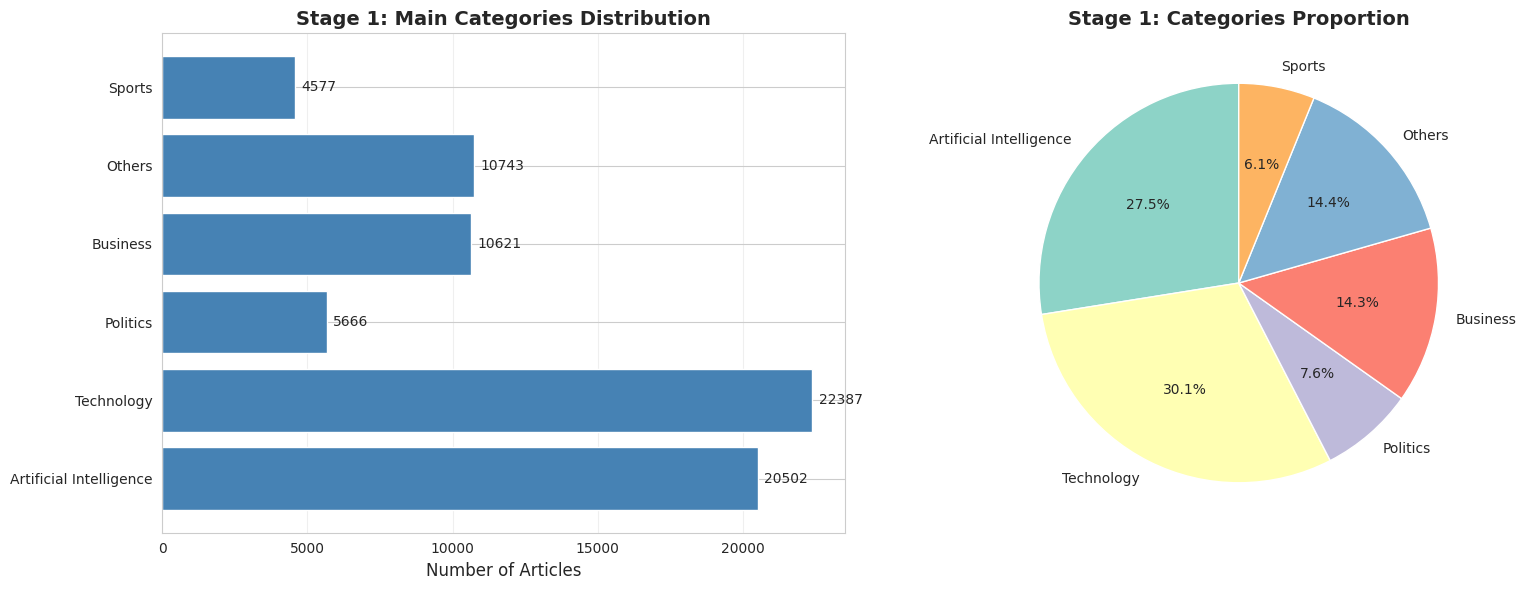


--- Stage 2: AI Ethics Issues Distribution (AI Articles Only) ---
Intellectual Property: 7939 articles
Bias And Fairness: 9058 articles
Surveillance And Regulation: 7219 articles
Privacy And Data Misuse: 9636 articles
Accountability And Liability: 11468 articles
Misinformation And Deepfakes: 6264 articles
Safety And Security: 8423 articles
Lack Of Transparency: 11566 articles
Job Displacement: 7378 articles
Algorithmic Manipulation: 10478 articles
Environmental Impact: 8525 articles
No Ethical Issue Detected: 3936 articles

✓ Stage 2 visualization saved: stage2_distribution.png


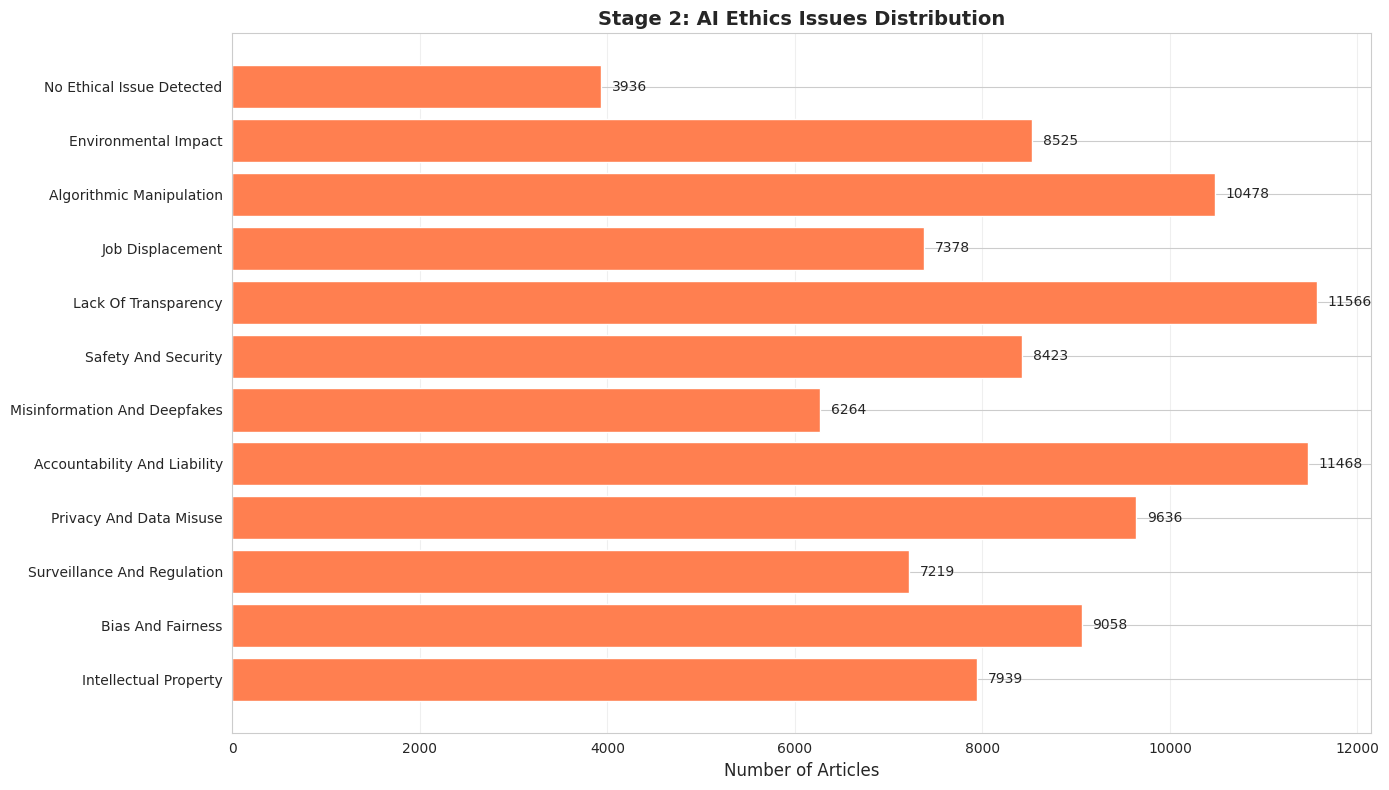


--- Multi-Label Co-occurrence Analysis ---

Stage 1 - Labels per article:
stage1_label_count
0     2042
1     2187
2    10222
3     3414
4     2832
5     1979
6     3400
Name: count, dtype: int64

Stage 2 - Labels per AI article:
stage2_label_count
0     3106
1     3325
2     2675
3     1462
4      901
5      730
6      620
7      756
8      836
9      994
10    1292
11    1651
12    2154
Name: count, dtype: int64

✓ Label count visualization saved: label_count_distribution.png


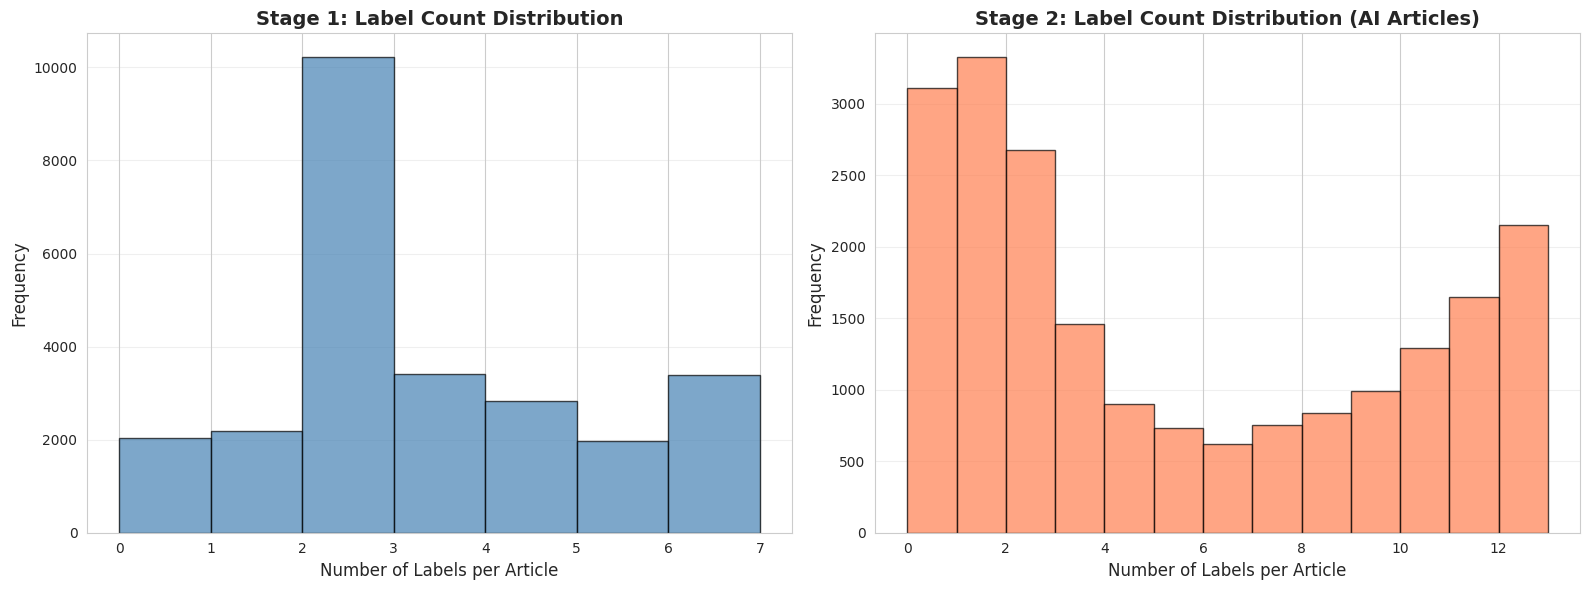


--- Top 10 Label Combinations (Stage 1) ---
Artificial Intelligence, Technology                                        8920
Artificial Intelligence, Technology, Politics, Business, Others, Sports    3400
Artificial Intelligence, Technology, Business, Others                      2092
No Labels                                                                  2042
Artificial Intelligence, Technology, Others                                1274
Artificial Intelligence, Technology, Business                              1254
Artificial Intelligence, Technology, Politics, Business, Others            1186
Technology                                                                  986
Artificial Intelligence                                                     785
Technology, Business, Others                                                561
Name: count, dtype: int64

LABELING & PREPROCESSING COMPLETE - FINAL SUMMARY

Total articles processed: 26076
AI articles (>= 50%): 20502
Non-AI articles (

In [3]:
"""
AI Ethics Radar - Stage 2 Only (Continue from Stage 1 results)
Loads labeled_stage1.csv and continues with:
- Stage 2: AI Ethics labeling
- Preprocessing
- EDA

Hardware: Kaggle T4 x2 GPU
"""

import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CONFIGURATION
# ============================================================================

# File paths
INPUT_STAGE1 = '/kaggle/input/stage1/labeled_stage1.csv'  # Update this path
OUTPUT_STAGE2 = 'labeled_stage2.csv'
OUTPUT_COMBINED = 'labeled_combined.csv'
OUTPUT_BINARY = 'labeled_binary.csv'
OUTPUT_TRAIN_STAGE1 = 'train_stage1.csv'
OUTPUT_VAL_STAGE1 = 'val_stage1.csv'
OUTPUT_TEST_STAGE1 = 'test_stage1.csv'
OUTPUT_TRAIN_STAGE2 = 'train_stage2.csv'
OUTPUT_VAL_STAGE2 = 'val_stage2.csv'
OUTPUT_TEST_STAGE2 = 'test_stage2.csv'

# Stage 1: Main Categories (for reference)
MAIN_CATEGORIES = [
    "Artificial Intelligence",
    "Technology", 
    "Business",
    "Politics",
    "Sports",
    "Others"
]

# Stage 2: AI Ethics Issues
ETHICS_LABELS = [
    "Bias & Fairness",
    "Privacy & Data Misuse",
    "Job Displacement",
    "Misinformation & Deepfakes",
    "Accountability & Liability",
    "Environmental Impact",
    "Surveillance & Regulation",
    "Safety & Security",
    "Intellectual Property",
    "Lack of Transparency",
    "Algorithmic Manipulation",
    "No Ethical Issue Detected"
]

# Hyperparameters
BATCH_SIZE = 16  # Adjust based on memory
TEXT_CHAR_LIMIT = 5000  # Use first 5000 characters
AI_THRESHOLD = 0.6  # 50% threshold for Stage 2
BINARY_THRESHOLD = 0.6  # Threshold for converting probabilities to binary
TRAIN_SIZE = 0.8
VAL_SIZE = 0.1
TEST_SIZE = 0.1
RANDOM_STATE = 42

DEVICE = 0 if torch.cuda.is_available() else -1

print(f"Using device: {'GPU' if DEVICE == 0 else 'CPU'}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============================================================================
# LOAD STAGE 1 RESULTS
# ============================================================================

print("\n" + "="*80)
print("LOADING STAGE 1 RESULTS")
print("="*80)

# Load Stage 1 results
df_stage1 = pd.read_csv(INPUT_STAGE1)
print(f"\nLoaded {len(df_stage1)} articles from {INPUT_STAGE1}")
print(f"Columns: {df_stage1.columns.tolist()}")

# Verify required columns exist
required_cols = ['content', 'stage1_artificial_intelligence']
missing_cols = [col for col in required_cols if col not in df_stage1.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print(f"\nStage 1 label columns found:")
stage1_label_cols = [col for col in df_stage1.columns if col.startswith('stage1_')]
for col in stage1_label_cols:
    print(f"  - {col}")

# ============================================================================
# STAGE 2: AI ETHICS LABELING
# ============================================================================

print("\n" + "="*80)
print("STAGE 2: LABELING AI ETHICS ISSUES (12 labels)")
print("="*80)

# Filter AI articles
ai_articles = df_stage1[df_stage1['stage1_artificial_intelligence'] >= AI_THRESHOLD].copy()
print(f"\nFound {len(ai_articles)} articles with AI probability >= {AI_THRESHOLD}")

if len(ai_articles) == 0:
    print("⚠ WARNING: No AI articles found! Check your threshold or Stage 1 results.")
    print("Exiting Stage 2...")
    stage2_results = []
    df_stage2 = ai_articles.copy()
else:
    # Initialize zero-shot classifier for Stage 2
    print("\nInitializing BART model for zero-shot classification...")
    classifier_stage2 = pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=DEVICE,
        multi_label=True
    )
    print("✓ Model loaded successfully")
    
    print(f"\nEthics Labels ({len(ETHICS_LABELS)} labels):")
    for i, label in enumerate(ETHICS_LABELS, 1):
        print(f"  {i}. {label}")
    
    print(f"\nUsing first {TEXT_CHAR_LIMIT} characters of each article")
    print(f"Processing {len(ai_articles)} AI articles in batches of {BATCH_SIZE}...")
    print(f"Estimated time: ~{(len(ai_articles) / BATCH_SIZE) * 10 / 60:.1f} minutes\n")
    
    # Store results
    stage2_results = []
    
    # Process in batches
    start_time = time.time()
    for i in tqdm(range(0, len(ai_articles), BATCH_SIZE), desc="Stage 2 Batches"):
        batch_texts = ai_articles['content'].iloc[i:i+BATCH_SIZE].tolist()
        
        # Truncate texts
        batch_texts = [text[:TEXT_CHAR_LIMIT] if isinstance(text, str) else "" for text in batch_texts]
        
        try:
            # Run zero-shot classification
            results = classifier_stage2(
                batch_texts,
                candidate_labels=ETHICS_LABELS,
                multi_label=True
            )
            
            # Handle both single and batch results
            if isinstance(results, dict):
                results = [results]
            
            # Extract probabilities
            for result in results:
                probs = {label: score for label, score in zip(result['labels'], result['scores'])}
                stage2_results.append(probs)
        
        except Exception as e:
            print(f"\nError processing batch {i}: {e}")
            # Add empty results for failed batch
            for _ in range(len(batch_texts)):
                stage2_results.append({label: 0.0 for label in ETHICS_LABELS})
    
    elapsed = time.time() - start_time
    print(f"\n✓ Stage 2 completed in {elapsed/60:.2f} minutes")
    print(f"  Average time per article: {elapsed/len(ai_articles):.2f} seconds")
    
    # Create DataFrame with Stage 2 results
    stage2_df = pd.DataFrame(stage2_results)
    stage2_df.columns = [f"stage2_{col.lower().replace(' ', '_').replace('&', 'and')}" 
                         for col in stage2_df.columns]
    
    # Combine with AI articles
    df_stage2 = pd.concat([ai_articles.reset_index(drop=True), stage2_df], axis=1)
    
    # Save Stage 2 results
    df_stage2.to_csv(OUTPUT_STAGE2, index=False)
    print(f"\n✓ Stage 2 results saved to: {OUTPUT_STAGE2}")
    
    # Statistics
    print("\n--- Stage 2 Statistics ---")
    for col in stage2_df.columns:
        if col.startswith('stage2_'):
            binary_count = (stage2_df[col] >= 0.5).sum()
            avg_prob = stage2_df[col].mean()
            pct = binary_count / len(stage2_df) * 100
            print(f"{col}: {binary_count} articles ({pct:.1f}% >= 50%), avg prob: {avg_prob:.3f}")

# ============================================================================
# COMBINE BOTH STAGES
# ============================================================================

print("\n" + "="*80)
print("COMBINING STAGE 1 & STAGE 2 RESULTS")
print("="*80)

# For non-AI articles, add zeros for Stage 2 labels
non_ai_articles = df_stage1[df_stage1['stage1_artificial_intelligence'] < AI_THRESHOLD].copy()
print(f"\nAI articles: {len(ai_articles)}")
print(f"Non-AI articles: {len(non_ai_articles)}")

# Add zero columns for Stage 2 to non-AI articles
for label in ETHICS_LABELS:
    col_name = f"stage2_{label.lower().replace(' ', '_').replace('&', 'and')}"
    non_ai_articles[col_name] = 0.0

# Combine AI and non-AI articles
if len(ai_articles) > 0:
    df_combined = pd.concat([df_stage2, non_ai_articles], ignore_index=True)
else:
    df_combined = non_ai_articles

# Save combined results
df_combined.to_csv(OUTPUT_COMBINED, index=False)
print(f"\n✓ Combined results saved to: {OUTPUT_COMBINED}")
print(f"  Total articles: {len(df_combined)}")

# ============================================================================
# PREPROCESSING: CONVERT TO BINARY LABELS
# ============================================================================

print("\n" + "="*80)
print("PREPROCESSING: CONVERTING PROBABILITIES TO BINARY LABELS")
print("="*80)

print(f"\nUsing threshold: {BINARY_THRESHOLD}")

# Create binary columns
df_binary = df_combined.copy()

# Convert Stage 1 probabilities to binary
stage1_prob_cols = [col for col in df_binary.columns if col.startswith('stage1_') and not col.startswith('stage1_binary_')]
print(f"\nConverting {len(stage1_prob_cols)} Stage 1 probability columns to binary...")
for col in stage1_prob_cols:
    binary_col = col.replace('stage1_', 'stage1_binary_')
    df_binary[binary_col] = (df_binary[col] >= BINARY_THRESHOLD).astype(int)

# Convert Stage 2 probabilities to binary
stage2_prob_cols = [col for col in df_binary.columns if col.startswith('stage2_') and not col.startswith('stage2_binary_')]
print(f"Converting {len(stage2_prob_cols)} Stage 2 probability columns to binary...")
for col in stage2_prob_cols:
    binary_col = col.replace('stage2_', 'stage2_binary_')
    df_binary[binary_col] = (df_binary[col] >= BINARY_THRESHOLD).astype(int)

# Save binary labels
df_binary.to_csv(OUTPUT_BINARY, index=False)
print(f"\n✓ Binary labels saved to: {OUTPUT_BINARY}")

print("\n--- Binary Label Counts (Stage 1) ---")
stage1_binary_cols = [col for col in df_binary.columns if col.startswith('stage1_binary_')]
for col in stage1_binary_cols:
    count = df_binary[col].sum()
    pct = count / len(df_binary) * 100
    print(f"{col}: {count} articles ({pct:.1f}%)")

print("\n--- Binary Label Counts (Stage 2 - AI articles only) ---")
ai_mask = df_binary['stage1_binary_artificial_intelligence'] == 1
stage2_binary_cols = [col for col in df_binary.columns if col.startswith('stage2_binary_')]
for col in stage2_binary_cols:
    count = df_binary[ai_mask][col].sum()
    total_ai = ai_mask.sum()
    pct = count / total_ai * 100 if total_ai > 0 else 0
    print(f"{col}: {count} articles ({pct:.1f}% of AI articles)")

# ============================================================================
# DATA SPLITTING
# ============================================================================

print("\n" + "="*80)
print("SPLITTING DATA INTO TRAIN/VAL/TEST")
print("="*80)

print(f"\nSplit ratios: Train={TRAIN_SIZE}, Val={VAL_SIZE}, Test={TEST_SIZE}")
print(f"Random state: {RANDOM_STATE}")

# Prepare columns for splitting
content_col = 'content'
stage1_label_cols = [col for col in df_binary.columns if col.startswith('stage1_binary_')]
stage2_label_cols = [col for col in df_binary.columns if col.startswith('stage2_binary_')]

# --- Stage 1 Split (All articles) ---
print("\n--- Stage 1 Data Split (All Articles) ---")

# Select relevant columns
stage1_data = df_binary[[content_col] + stage1_label_cols].copy()

# First split: train+val vs test
train_val_s1, test_s1 = train_test_split(
    stage1_data, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

# Second split: train vs val
val_size_adjusted = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
train_s1, val_s1 = train_test_split(
    train_val_s1, 
    test_size=val_size_adjusted, 
    random_state=RANDOM_STATE
)

# Save Stage 1 splits
train_s1.to_csv(OUTPUT_TRAIN_STAGE1, index=False)
val_s1.to_csv(OUTPUT_VAL_STAGE1, index=False)
test_s1.to_csv(OUTPUT_TEST_STAGE1, index=False)

print(f"Train: {len(train_s1)} articles ({len(train_s1)/len(stage1_data)*100:.1f}%)")
print(f"Val: {len(val_s1)} articles ({len(val_s1)/len(stage1_data)*100:.1f}%)")
print(f"Test: {len(test_s1)} articles ({len(test_s1)/len(stage1_data)*100:.1f}%)")
print(f"✓ Saved to: {OUTPUT_TRAIN_STAGE1}, {OUTPUT_VAL_STAGE1}, {OUTPUT_TEST_STAGE1}")

# --- Stage 2 Split (AI articles only) ---
print("\n--- Stage 2 Data Split (AI Articles Only) ---")

# Filter AI articles
stage2_data = df_binary[df_binary['stage1_binary_artificial_intelligence'] == 1][[content_col] + stage2_label_cols].copy()

if len(stage2_data) < 100:
    print(f"⚠ WARNING: Only {len(stage2_data)} AI articles found. This might be too few for training!")
    print("Skipping Stage 2 split...")
else:
    # First split: train+val vs test
    train_val_s2, test_s2 = train_test_split(
        stage2_data, 
        test_size=TEST_SIZE, 
        random_state=RANDOM_STATE
    )
    
    # Second split: train vs val
    train_s2, val_s2 = train_test_split(
        train_val_s2, 
        test_size=val_size_adjusted, 
        random_state=RANDOM_STATE
    )
    
    # Save Stage 2 splits
    train_s2.to_csv(OUTPUT_TRAIN_STAGE2, index=False)
    val_s2.to_csv(OUTPUT_VAL_STAGE2, index=False)
    test_s2.to_csv(OUTPUT_TEST_STAGE2, index=False)
    
    print(f"Train: {len(train_s2)} articles ({len(train_s2)/len(stage2_data)*100:.1f}%)")
    print(f"Val: {len(val_s2)} articles ({len(val_s2)/len(stage2_data)*100:.1f}%)")
    print(f"Test: {len(test_s2)} articles ({len(test_s2)/len(stage2_data)*100:.1f}%)")
    print(f"✓ Saved to: {OUTPUT_TRAIN_STAGE2}, {OUTPUT_VAL_STAGE2}, {OUTPUT_TEST_STAGE2}")

# ============================================================================
# EDA: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# --- Stage 1: Main Categories Distribution ---
print("\n--- Stage 1: Main Categories Distribution ---")

stage1_counts = []
stage1_labels = []
for col in stage1_binary_cols:
    label = col.replace('stage1_binary_', '').replace('_', ' ').title()
    count = df_binary[col].sum()
    stage1_counts.append(count)
    stage1_labels.append(label)
    print(f"{label}: {count} articles")

# Plot Stage 1 distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1.barh(stage1_labels, stage1_counts, color='steelblue')
ax1.set_xlabel('Number of Articles', fontsize=12)
ax1.set_title('Stage 1: Main Categories Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(stage1_counts):
    ax1.text(v + max(stage1_counts)*0.01, i, str(v), va='center', fontsize=10)

# Pie chart
colors = plt.cm.Set3(range(len(stage1_labels)))
ax2.pie(stage1_counts, labels=stage1_labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Stage 1: Categories Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('stage1_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Stage 1 visualization saved: stage1_distribution.png")
plt.show()

# --- Stage 2: AI Ethics Issues Distribution ---
if len(stage2_data) > 0:
    print("\n--- Stage 2: AI Ethics Issues Distribution (AI Articles Only) ---")
    
    stage2_counts = []
    stage2_labels = []
    for col in stage2_binary_cols:
        label = col.replace('stage2_binary_', '').replace('_', ' ').title()
        count = df_binary[ai_mask][col].sum()
        stage2_counts.append(count)
        stage2_labels.append(label)
        print(f"{label}: {count} articles")
    
    # Plot Stage 2 distribution
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Horizontal bar chart
    bars = ax.barh(stage2_labels, stage2_counts, color='coral')
    ax.set_xlabel('Number of Articles', fontsize=12)
    ax.set_title('Stage 2: AI Ethics Issues Distribution', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(stage2_counts):
        ax.text(v + max(stage2_counts)*0.01, i, str(v), va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('stage2_distribution.png', dpi=300, bbox_inches='tight')
    print("\n✓ Stage 2 visualization saved: stage2_distribution.png")
    plt.show()

# --- Multi-Label Co-occurrence Analysis ---
print("\n--- Multi-Label Co-occurrence Analysis ---")

# Stage 1: How many labels per article?
df_binary['stage1_label_count'] = df_binary[stage1_binary_cols].sum(axis=1)
print("\nStage 1 - Labels per article:")
print(df_binary['stage1_label_count'].value_counts().sort_index())

# Stage 2: How many labels per AI article?
if len(stage2_data) > 0:
    df_binary['stage2_label_count'] = df_binary[stage2_binary_cols].sum(axis=1)
    ai_label_counts = df_binary[ai_mask]['stage2_label_count']
    print("\nStage 2 - Labels per AI article:")
    print(ai_label_counts.value_counts().sort_index())

# Plot label count distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stage 1
axes[0].hist(df_binary['stage1_label_count'], bins=range(0, 8), color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Labels per Article', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Stage 1: Label Count Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Stage 2
if len(stage2_data) > 0:
    axes[1].hist(ai_label_counts, bins=range(0, 14), color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Number of Labels per Article', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Stage 2: Label Count Distribution (AI Articles)', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('label_count_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Label count visualization saved: label_count_distribution.png")
plt.show()

# --- Top Label Combinations (Stage 1) ---
print("\n--- Top 10 Label Combinations (Stage 1) ---")
label_combinations = df_binary[stage1_binary_cols].apply(
    lambda row: ', '.join([col.replace('stage1_binary_', '').replace('_', ' ').title() 
                          for col, val in row.items() if val == 1]), 
    axis=1
)
label_combinations = label_combinations.replace('', 'No Labels')
top_combinations = label_combinations.value_counts().head(10)
print(top_combinations)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("LABELING & PREPROCESSING COMPLETE - FINAL SUMMARY")
print("="*80)

print(f"\nTotal articles processed: {len(df_combined)}")
print(f"AI articles (>= 50%): {len(ai_articles) if len(ai_articles) > 0 else 0}")
print(f"Non-AI articles (< 50%): {len(non_ai_articles)}")

print("\n--- Output Files ---")
print("Probability Labels:")
print(f"  1. Stage 2 only (AI articles): {OUTPUT_STAGE2}")
print(f"  2. Combined (all articles): {OUTPUT_COMBINED}")
print("\nBinary Labels:")
print(f"  3. Binary labels: {OUTPUT_BINARY}")
print("\nTrain/Val/Test Splits:")
print(f"  Stage 1:")
print(f"    4. Train: {OUTPUT_TRAIN_STAGE1}")
print(f"    5. Val: {OUTPUT_VAL_STAGE1}")
print(f"    6. Test: {OUTPUT_TEST_STAGE1}")
if len(stage2_data) >= 100:
    print(f"  Stage 2:")
    print(f"    7. Train: {OUTPUT_TRAIN_STAGE2}")
    print(f"    8. Val: {OUTPUT_VAL_STAGE2}")
    print(f"    9. Test: {OUTPUT_TEST_STAGE2}")

print("\n--- Dataset Statistics ---")
print(f"Stage 1 (Main Categories):")
print(f"  Train: {len(train_s1)} | Val: {len(val_s1)} | Test: {len(test_s1)}")
if len(stage2_data) >= 100:
    print(f"Stage 2 (AI Ethics):")
    print(f"  Train: {len(train_s2)} | Val: {len(val_s2)} | Test: {len(test_s2)}")

print("\n--- Visualizations Generated ---")
print("  1. stage1_distribution.png")
if len(stage2_data) > 0:
    print("  2. stage2_distribution.png")
print("  3. label_count_distribution.png")

print("\n" + "="*80)
print("✓ ALL DONE! Ready for model training.")
print("="*80)